In [1]:
# INSTALL
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.0 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
# BASELINE MODEL
baseline_model = keras.Sequential([
    keras.Input(shape=(28,28,1)),
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

In [5]:
baseline_history = baseline_model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(patience=3)]
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.8537 - loss: 0.4123 - val_accuracy: 0.8865 - val_loss: 0.3191
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8992 - loss: 0.2817 - val_accuracy: 0.9003 - val_loss: 0.2743
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.9152 - loss: 0.2323 - val_accuracy: 0.9077 - val_loss: 0.2536
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9280 - loss: 0.1976 - val_accuracy: 0.9107 - val_loss: 0.2439
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9369 - loss: 0.1695 - val_accuracy: 0.9100 - val_loss: 0.2555
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9476 - loss: 0.1442 - val_accuracy: 0.9119 - val_loss: 0.2603
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9557 - loss: 0.1206 - val_accuracy: 0.9131 - val_loss: 0.2676


In [6]:
# TUNER MODEL
def build_model(hp):
    model = keras.Sequential([
        keras.Input(shape=(28,28,1)),
        layers.Conv2D(32,(3,3),activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(hp.Int('units',32,512,step=32),activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    lr = hp.Choice('learning_rate',[0.01,0.001,0.0001])

    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [7]:
tuner = kt.RandomSearch(build_model,
                        objective='val_accuracy',
                        max_trials=5,
                        directory='fashion',
                        project_name='cnn')

tuner.search(x_train, y_train, epochs=10, validation_split=0.2)

best_hp = tuner.get_best_hyperparameters(1)[0]

Trial 5 Complete [00h 05m 03s]
val_accuracy: 0.9183333516120911

Best val_accuracy So Far: 0.9183333516120911
Total elapsed time: 00h 28m 49s


In [8]:
# BEST MODEL
best_model = tuner.hypermodel.build(best_hp)
-
best_history = best_model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(patience=3)]
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8526 - loss: 0.4123 - val_accuracy: 0.8928 - val_loss: 0.2977
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9014 - loss: 0.2706 - val_accuracy: 0.9031 - val_loss: 0.2709
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9181 - loss: 0.2222 - val_accuracy: 0.9032 - val_loss: 0.2654
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9306 - loss: 0.1862 - val_accuracy: 0.9100 - val_loss: 0.2524
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9426 - loss: 0.1554 - val_accuracy: 0.9147 - val_loss: 0.2437
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9528 - loss: 0.1295 - val_accuracy: 0.9131 - val_loss: 0.2721
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9616 - loss: 0.1044 - val_accuracy: 0.9168 - val_loss: 0.2617
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.9684 -

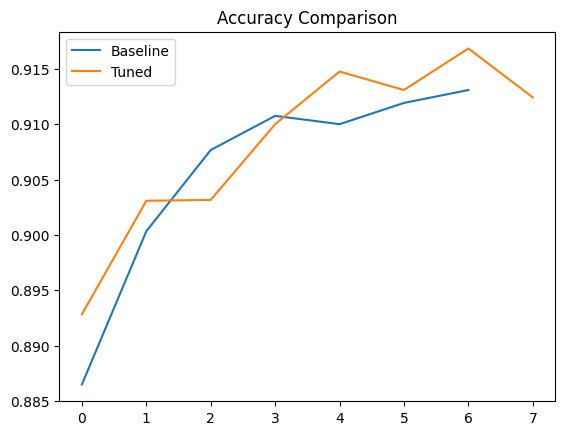

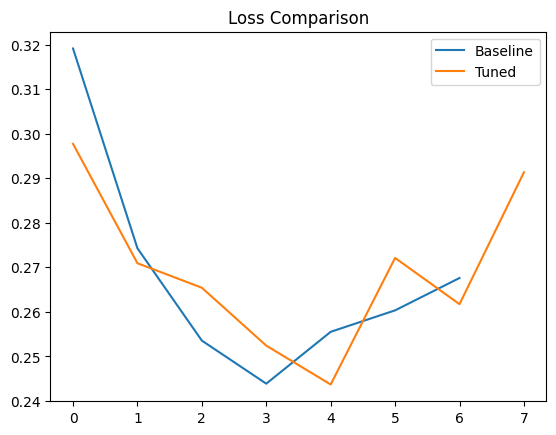

Best Units: 224
Best LR: 0.001
Baseline Acc: 0.9130833148956299
Tuned Acc: 0.9168333411216736


In [9]:
# PLOTS
plt.figure()
plt.plot(baseline_history.history['val_accuracy'], label='Baseline')
plt.plot(best_history.history['val_accuracy'], label='Tuned')
plt.legend()
plt.title("Accuracy Comparison")
plt.show()

plt.figure()
plt.plot(baseline_history.history['val_loss'], label='Baseline')
plt.plot(best_history.history['val_loss'], label='Tuned')
plt.legend()
plt.title("Loss Comparison")
plt.show()

# RESULTS
print("Best Units:", best_hp.get('units'))
print("Best LR:", best_hp.get('learning_rate'))
print("Baseline Acc:", max(baseline_history.history['val_accuracy']))
print("Tuned Acc:", max(best_history.history['val_accuracy']))